# Examen Supletorio ITQ Machine Elerarning

nombre : Andres Aguiar

## 01 - 1.25pt
- Crear un array de NumPy de dimensiones 5x5, con números enteros aleatorios en el rango [-40, 40]
- Hacer los siguientes reemplazos en orden
    - Reemplazar todos los valores multiplos de 3 por 1
    - Reemplazar todos los valores pares positivos por 0
    - Reemplazar todos los valores pares negativos por Nan
- Averiguar cuantos elementos tienen Nan por fila

In [3]:
import numpy as np

np.random.seed(42)
array = np.random.randint(-40, 41, size=(5, 5))
array = array.astype(float)

print("Array Original")
print(array)
print("\n")

array[array % 3 == 0] = 1

array[(array > 0) & (array % 2 == 0)] = 0

array[(array < 0) & (array % 2 == 0)] = np.nan

print("Array con Reemplazos")
print(array)
print("\n")

nans_por_fila = np.isnan(array).sum(axis=1)

print("Cantidad de NaN por fila")
print(nans_por_fila)

Array Original
[[ 11. -26.  31.  20. -20.]
 [ 34.  34. -17. -38. -19.]
 [ 12. -39. -11.  -3. -39.]
 [ 23.  19. -20.  -8.  35.]
 [ 17. -19.   8.  18.   1.]]


Array con Reemplazos
[[ 11.  nan  31.   0.  nan]
 [  0.   0. -17.  nan -19.]
 [  1.   1. -11.   1.   1.]
 [ 23.  19.  nan  nan  35.]
 [ 17. -19.   0.   1.   1.]]


Cantidad de NaN por fila
[2 1 0 2 0]


## 02 - 1.25pt
- Escribe una función que cada vez que se le invoque devuelva el factorial del siguiente número entero, empezando por 1, hasta cualquier número infinito

In [15]:
class MotorFactorial:
    def __init__(self):
        self.valor_actual = 0
        self.calculo = 1
    
    def __iter__(self):
        return self
    
    def __next__(self):
        self.valor_actual += 1
        self.calculo *= self.valor_actual
        return self.calculo

def fact_gen():
    return MotorFactorial()

    expected_output = [1, 2, 6, 24, 120, 720, 5040, 40320]

g = fact_gen() # This calls your function named fact_gen
output = [next(g) for n in range(len(expected_output))]

print("Obtenido:", output)

assert(expected_output == output) # This calls your function named fact_gen

Obtenido: [1, 2, 6, 24, 120, 720, 5040, 40320]


## 03 - 1.25pt
- Escribir una función que reciba un Dataframe, en la columna "name" convierta el primer carácter de cada nombre a mayúsculas.

In [4]:
import pandas as pd
def capitalize_name(dataframe):
    dataframe['name'] = dataframe['name'].str.capitalize()
    return dataframe
    
dataframe = pd.DataFrame({
    'name': ['tamayo','tanjiro','inosuke', 'zenitsu', 'nezuko'],
    'date_of_birth ': ['13/01/2002','18/03/1999','21/11/1998','10/10/2002','05/04/1997'],
    'age': [18.5, 21.2, 22.5, 22, 23]
})

expected_output = pd.DataFrame({
    'name': ['Tamayo', 'Tanjiro', 'Inosuke', 'Zenitsu', 'Nezuko'],
    'date_of_birth ': ['13/01/2002','18/03/1999','21/11/1998','10/10/2002','05/04/1997'],
    'age': [18.5, 21.2, 22.5, 22, 23]
})

output = capitalize_name(dataframe) # This calls your function capitalize_name

display(expected_output)
display(output)

assert(expected_output.equals(output)) # This will fail if result is not as expected

,name,date_of_birth,age
0,Tamayo,13/01/2002,18.5
1,Tanjiro,18/03/1999,21.2
2,Inosuke,21/11/1998,22.5
3,Zenitsu,10/10/2002,22.0
4,Nezuko,05/04/1997,23.0


,name,date_of_birth,age
0,Tamayo,13/01/2002,18.5
1,Tanjiro,18/03/1999,21.2
2,Inosuke,21/11/1998,22.5
3,Zenitsu,10/10/2002,22.0
4,Nezuko,05/04/1997,23.0


## 04 - 1.25pt
- 200 personas hacen una review de una película, dándole una puntuación de 0.0 a 5.0 a dicha película
- Crear una lista aleatoria con las posibles puntuaciones, es decir, 200 puntuaciones entre 0.0 y 5.0
- Discretizar dichas puntuaciones en 4 categorias [muy mala, mala, buena, excelente], los límites de cada categoría son a libre elección
- Discretizar dichas puntuaciones en 5 categorías distribuidas con rangos homogéneos (similar cantidad de valores en cada categoría)
- Mostrar las categorías creadas y cuantos elementos hay en cada una de ellas

In [10]:
import numpy as np
import pandas as pd


In [11]:

np.random.seed(42)
puntuaciones = np.random.uniform(0.0, 5.0, 200)

df = pd.DataFrame(puntuaciones, columns=['puntuacion'])

bins = [0.0, 2.0, 3.5, 4.5, 5.0]
labels = ['muy mala', 'mala', 'buena', 'excelente']

df['categoria_libre'] = pd.cut(df['puntuacion'], bins=bins, labels=labels, include_lowest=True)

df['categoria_homogenea'] = pd.qcut(df['puntuacion'], q=5)

print("Categorías Libres")
conteo_libre = df.groupby('categoria_libre')['puntuacion'].count()
print(conteo_libre)
print("\n")

print("Categorías Homogéneas")
conteo_homogeneo = df.groupby('categoria_homogenea')['puntuacion'].count()
print(conteo_homogeneo)

Categorías Libres
categoria_libre
muy mala     90
mala         50
buena        41
excelente    19
Name: puntuacion, dtype: int64


Categorías Homogéneas
categoria_homogenea
(0.0266, 0.923]    40
(0.923, 1.701]     40
(1.701, 2.973]     40
(2.973, 4.022]     40
(4.022, 4.934]     40
Name: puntuacion, dtype: int64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10772\208507623.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_libre = df.groupby('categoria_libre')['puntuacion'].count()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10772\208507623.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_homogeneo = df.groupby('categoria_homogenea')['puntuacion'].count()


## 05 - 5pt

El conjunto de datos "estaciones_bici.csv" (fichero disponible adjunto a la actividad) proviene de una descarga de datos del servicio web de la empresa municipal Valenbici, dedicada al alquiler de bicicletas en Valencia.

Los datos recabados de este servicio web son de mediciones cada 10 minutos de las estaciones:

https://valencia.opendatasoft.com/explore/dataset/valenbisi-disponibilitat-valenbisi-dsiponibilidad/information/

Cada estación está compuesta por un número variable de bornetas (total) donde se pueden anclar las bicicletas. Los datos obtenidos de cada estación (registros) refleja el número de bornetas libres (free) y el número de bicicletas disponibles (available).

#### Columnas para trabajar:
- station: id de la estación
- total: número total de bornetas
- updated: timestamp del estado en de bicis en la estación
- available: número de bicis disponibles

#### Preguntas
1. Carga de datos de csv (estaciones_bici.csv) en un DataFrame
2. ¿Cuál es el rango temporal del dataset? Obtención del número de estaciones que tienen un total de 30 bornetas
3. Número de estación con la media más alta de bicis disponibles
4. Realizar el histograma de bicis disponibles de la estación del punto anterior
5. Realizar gráfica con  la línea temporal de bicis disponibles de la estación del punto anterior. Pista, es necesario cambiar el índice a uno tipo fecha

In [48]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [40]:
# 1. Carga de datos de csv (estaciones_bici.csv) en un DataFrame

In [53]:
ruta_csv = "estaciones_bici.csv"
df_bici = pd.read_csv(ruta_csv, sep=';')
df_bici.columns = df_bici.columns.str.strip()

In [50]:
# 2. ¿Cuál es el rango temporal del dataset

In [54]:
df_bici['updated'] = pd.to_datetime(df_bici['updated'])
print(f"Rango: {df_bici['updated'].min()} a {df_bici['updated'].max()}")

estaciones_30 = df_bici[df_bici['total'] == 30]['station'].unique()
print(f"Estaciones con 30 bornetas: {len(estaciones_30)}")

Rango: 2019-02-10 17:21:13 a 2019-02-11 23:42:16
Estaciones con 30 bornetas: 11


In [ ]:
# 2.b Obtención del número de estaciones que tienen un total de 30 bornetas

In [ ]:
# 3. Número de estación con la media más alta de bicis disponibles

In [55]:
media_est = df_bici.groupby('station', observed=False)['available'].mean()
id_max = media_est.idxmax()
print(f"Estación con media más alta: {id_max}")

Estación con media más alta: 50


In [ ]:
# 4. Realizar el histograma de bicis disponibles de la estación del punto anterior

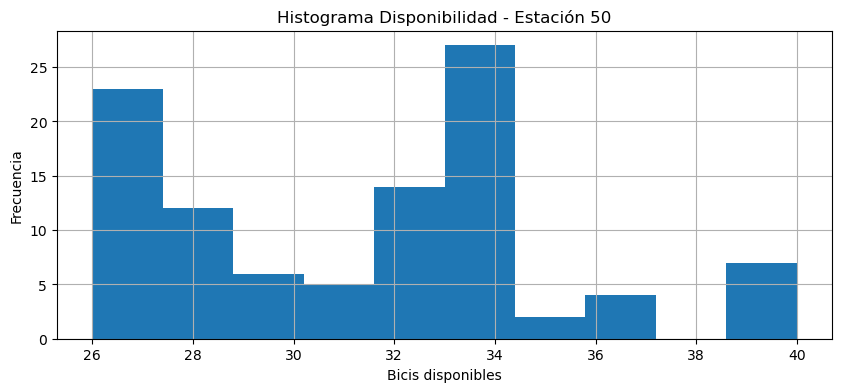

In [56]:
plt.figure(figsize=(10, 4))
df_bici[df_bici['station'] == id_max]['available'].hist()
plt.title(f"Histograma Disponibilidad - Estación {id_max}")
plt.xlabel("Bicis disponibles")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# 5. Realizar gráfica con  la línea temporal de bicis disponibles de la estación del punto anterior. Pista, es necesario cambiar el tipo de dato a uno tipo fecha

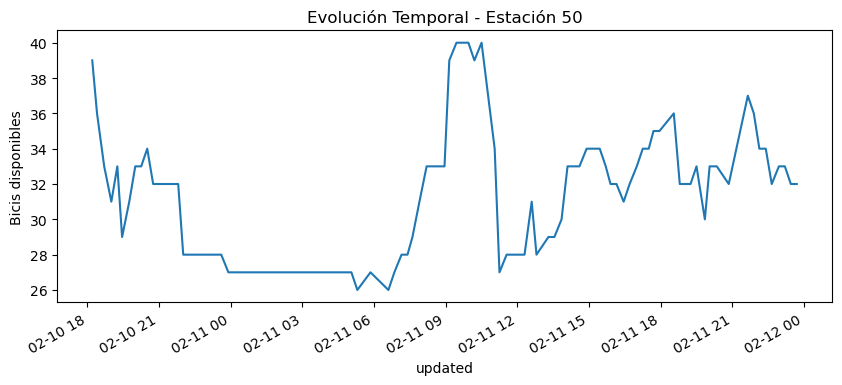

In [57]:
df_linea = df_bici[df_bici['station'] == id_max].copy()
df_linea.set_index('updated', inplace=True)
df_linea.sort_index(inplace=True)

plt.figure(figsize=(10, 4))
df_linea['available'].plot()
plt.title(f"Evolución Temporal - Estación {id_max}")
plt.ylabel("Bicis disponibles")
plt.show()